In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

print('All imports successful!')

All imports successful!


In [2]:
import xarray as xr
from pathlib import Path

TRAIN_PATH = Path(r'D:\Desktop\machine learning\data\train.nc')
ds = xr.open_dataset(TRAIN_PATH, engine='netcdf4')
print(ds)

<xarray.Dataset> Size: 159MB
Dimensions:    (location: 83, timestamp: 2161, feature: 109)
Coordinates:
  * location   (location) <U5 2kB '26001' '26003' '26005' ... '26163' '26165'
    state      (location) <U2 664B ...
  * timestamp  (timestamp) datetime64[ns] 17kB 2023-04-01 ... 2023-06-30
  * feature    (feature) object 872B 'SBT113' 'SBT114' 'SBT123' ... 'wz' 'wz_1'
Data variables:
    tracked    (location, timestamp) float64 1MB ...
    out        (location, timestamp) float64 1MB ...
    weather    (location, timestamp, feature) float64 156MB ...
Attributes:
    time_start:  2022-01-01T00:00:00
    time_end:    2022-01-31T23:00:00
    time_now:    2025-07-08T14:59:10


In [3]:
# Extract core data as numpy arrays
out = ds.out.transpose('timestamp', 'location').values.astype(float)         # (T, L)
tracked = ds.tracked.transpose('timestamp', 'location').values.astype(float) # (T, L)
weather = ds.weather.transpose('timestamp', 'location', 'feature').values.astype(float)  # (T, L, F)

timestamps = pd.to_datetime(ds.timestamp.values)
locations = [str(loc) for loc in ds.location.values]
features = [str(f) for f in ds.feature.values]

T, L = out.shape
F = len(features)
print(f'out shape:     {out.shape}  (T={T}, L={L})')
print(f'tracked shape: {tracked.shape}')
print(f'weather shape: {weather.shape}  (T={T}, L={L}, F={F})')
print(f'\nWeather feature list:\n{features}')

out shape:     (2161, 83)  (T=2161, L=83)
tracked shape: (2161, 83)
weather shape: (2161, 83, 109)  (T=2161, L=83, F=109)

Weather feature list:
['SBT113', 'SBT114', 'SBT123', 'SBT124', 'aod', 'bgrun', 'blh', 'cape', 'cape_1', 'cfnsf', 'cfrzr', 'cicep', 'cin', 'cnwat', 'cpofp', 'crain', 'csnow', 'd2m', 'fricv', 'frzr', 'fsr', 'gflux', 'gh', 'gh_1', 'gh_2', 'gh_3', 'gh_4', 'gh_5', 'gh_6', 'gh_7', 'gust', 'hail', 'hail_1', 'hail_2', 'hcc', 'ishf', 'lai', 'layth', 'lcc', 'lftx', 'lftx4', 'lsm', 'ltng', 'max_10si', 'mcc', 'mdens', 'mslma', 'mstav', 'orog', 'pcdb', 'plpl', 'prate', 'pres', 'pres_1', 'pres_2', 'pt', 'pwat', 'r', 'r2', 'r_1', 'refc', 'refd', 'refd_1', 'sde', 'sdlwrf', 'sdswrf', 'sdwe', 'sdwe_1', 'sh2', 'siconc', 'slhtf', 'snowc', 'sp', 'ssrun', 'sulwrf', 'suswrf', 't', 't2m', 'tcc', 'tcc_1', 'tcoli', 'tcolw', 'tp', 'u', 'u10', 'unknown', 'unknown_1', 'unknown_2', 'unknown_3', 'unknown_4', 'unknown_5', 'unknown_6', 'unknown_7', 'unknown_8', 'unknown_9', 'ustm', 'v', 'v10', 'vb

In [4]:
import numpy as np

# add log-transformed outage variable into xarray dataset
ds["log_out"] = np.log1p(ds["out"])

print(ds)
print(ds["log_out"])

<xarray.Dataset> Size: 161MB
Dimensions:    (location: 83, timestamp: 2161, feature: 109)
Coordinates:
  * location   (location) <U5 2kB '26001' '26003' '26005' ... '26163' '26165'
    state      (location) <U2 664B ...
  * timestamp  (timestamp) datetime64[ns] 17kB 2023-04-01 ... 2023-06-30
  * feature    (feature) object 872B 'SBT113' 'SBT114' 'SBT123' ... 'wz' 'wz_1'
Data variables:
    tracked    (location, timestamp) float64 1MB ...
    out        (location, timestamp) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    weather    (location, timestamp, feature) float64 156MB ...
    log_out    (location, timestamp) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    time_start:  2022-01-01T00:00:00
    time_end:    2022-01-31T23:00:00
    time_now:    2025-07-08T14:59:10
<xarray.DataArray 'log_out' (location: 83, timestamp: 2161)> Size: 1MB
array([[0.        , 0.        , 0.        , ..., 6.83947644, 6.97447891,
        2.39789527],
       [0.69314718, 0.        , 0.        , 

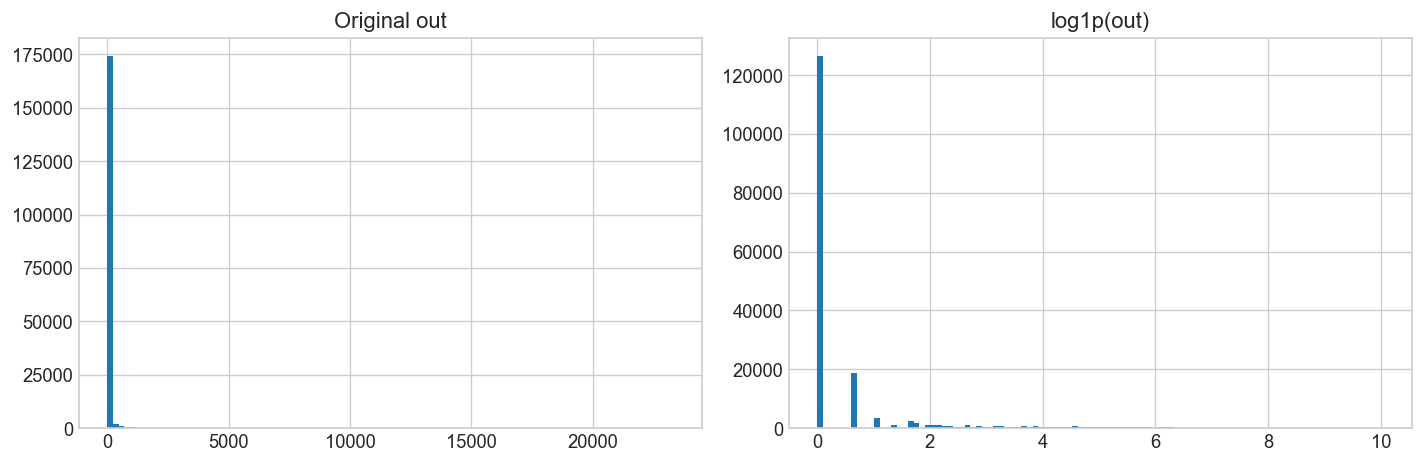

In [5]:
import matplotlib.pyplot as plt

out_flat = ds["out"].values.flatten()
log_out_flat = np.log1p(out_flat)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(out_flat[~np.isnan(out_flat)], bins=100)
plt.title("Original out")

plt.subplot(1, 2, 2)
plt.hist(log_out_flat[~np.isnan(log_out_flat)], bins=100)
plt.title("log1p(out)")

plt.tight_layout()
plt.show()

In [6]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path

# ===== 1. Paths =====
BASE_DIR = Path(r"D:\Desktop\machine learning")
DATA_DIR = BASE_DIR / "data"

input_path = DATA_DIR / "train.nc"
output_path = DATA_DIR / "county_sheets_with_log_out.xlsx"

print(f"Reading from: {input_path}")
print(f"File exists: {input_path.exists()}")

# ===== 2. Load dataset =====
ds = xr.open_dataset(input_path, engine="netcdf4")

# ===== 3. Create log_out =====
ds["log_out"] = np.log1p(ds["out"])

# ===== 4. Weather long -> wide =====
weather_df = ds["weather"].to_dataframe().reset_index()

weather_wide = weather_df.pivot_table(
    index=["location", "timestamp"],
    columns="feature",
    values="weather"
).reset_index()

weather_wide.columns.name = None

# ===== 5. Base dataframe =====
base_df = ds[["tracked", "out", "log_out"]].to_dataframe().reset_index()

# Add state if it exists
if "state" in ds:
    state_df = ds["state"].to_dataframe().reset_index()
    base_df = base_df.merge(state_df, on="location", how="left")
elif "state" in ds.coords:
    state_df = ds.coords["state"].to_dataframe().reset_index()
    base_df = base_df.merge(state_df, on="location", how="left")

# ===== 6. Drop duplicates =====
base_df = base_df.drop_duplicates(subset=["location", "timestamp"])

# ===== 7. Merge all =====
final_df = base_df.merge(
    weather_wide,
    on=["location", "timestamp"],
    how="left"
)

# ===== 8. Reorder columns =====
front_cols = [
    col for col in ["location", "state", "timestamp", "tracked", "out", "log_out"]
    if col in final_df.columns
]
other_cols = [col for col in final_df.columns if col not in front_cols]

final_df = final_df[front_cols + other_cols]
final_df = final_df.sort_values(["location", "timestamp"]).reset_index(drop=True)

# ===== 9. Write each location to one sheet =====
output_path.parent.mkdir(parents=True, exist_ok=True)

locations = final_df["location"].dropna().astype(str).unique()
used_sheet_names = set()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for i, loc in enumerate(locations, start=1):
        county_df = final_df[final_df["location"].astype(str) == loc].copy()

        # Excel sheet name max length = 31
        base_sheet_name = str(loc)[:31]
        sheet_name = base_sheet_name

        # Handle duplicate sheet names safely
        counter = 1
        while sheet_name in used_sheet_names:
            suffix = f"_{counter}"
            sheet_name = base_sheet_name[:31 - len(suffix)] + suffix
            counter += 1

        used_sheet_names.add(sheet_name)
        county_df.to_excel(writer, sheet_name=sheet_name, index=False)

        if i % 10 == 0 or i == len(locations):
            print(f"Written {i}/{len(locations)} sheets...")

print(f"\nDone. Saved to: {output_path}")
print(f"Total sheets created: {len(locations)}")

Reading from: D:\Desktop\machine learning\data\train.nc
File exists: True
Written 10/83 sheets...
Written 20/83 sheets...
Written 30/83 sheets...
Written 40/83 sheets...
Written 50/83 sheets...
Written 60/83 sheets...
Written 70/83 sheets...
Written 80/83 sheets...
Written 83/83 sheets...

Done. Saved to: D:\Desktop\machine learning\data\county_sheets_with_log_out.xlsx
Total sheets created: 83


In [7]:
import xarray as xr
import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

# 1. load data
BASE_DIR = Path(r"D:\Desktop\machine learning")
DATA_DIR = BASE_DIR / "data"
input_path = DATA_DIR / "train.nc"

print(f"Reading from: {input_path}")
print(f"File exists: {input_path.exists()}")

ds = xr.open_dataset(input_path, engine="netcdf4")

# 2. make sure dimensions are (timestamp, location)
out_da = ds["out"].transpose("timestamp", "location")
tracked_da = ds["tracked"].transpose("timestamp", "location")

locations = ds["location"].values.astype(str)
out = out_da.values
tracked = tracked_da.values

# 3. county summary
county_mean = np.nanmean(out, axis=0)
county_tracked = np.nanmean(tracked, axis=0)

# avoid divide-by-zero
ratio_array = np.where(tracked == 0, np.nan, out / tracked)
county_ratio = np.nanmean(ratio_array, axis=0)

map_df = pd.DataFrame({
    "fips": locations,
    "mean_outage": county_mean,
    "mean_tracked": county_tracked,
    "outage_ratio": county_ratio
})

# keep fips as 5-digit string
map_df["fips"] = map_df["fips"].astype(str).str.zfill(5)

# optional: keep only Michigan counties
map_df = map_df[map_df["fips"].str.startswith("26")].copy()

print(map_df.head())
print("Number of counties:", len(map_df))

# 4. plot map
fig = px.choropleth(
    map_df,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="outage_ratio",
    color_continuous_scale="Reds",
    scope="usa",
    hover_data={
        "fips": True,
        "mean_outage": ':.2f',
        "mean_tracked": ':.0f',
        "outage_ratio": ':.4f'
    },
    labels={"outage_ratio": "Mean Outage Ratio"},
    title="Michigan County Map - Mean Outage Ratio"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})

fig.show()

Reading from: D:\Desktop\machine learning\data\train.nc
File exists: True
    fips  mean_outage  mean_tracked  outage_ratio
0  26001    14.038871  12526.020361      0.001123
1  26003    33.974086   9216.727441      0.003686
2  26005    25.361407  61684.771865      0.000412
3  26007     0.323924   3503.617770      0.000092
4  26009    14.307728  21215.930125      0.000680
Number of counties: 83


In [8]:
# Basic statistics
out_flat = out.flatten()
out_flat_nonzero = out_flat[out_flat > 0]

print('=== Global Outage Statistics ===')
print(f'Mean:        {np.nanmean(out_flat):.2f}')
print(f'Median:      {np.nanmedian(out_flat):.2f}')
print(f'Std Dev:     {np.nanstd(out_flat):.2f}')
print(f'Min:         {np.nanmin(out_flat):.0f}')
print(f'Max:         {np.nanmax(out_flat):.0f}')
print(f'Skewness:    {stats.skew(out_flat[~np.isnan(out_flat)]):.2f}')
print(f'Kurtosis:    {stats.kurtosis(out_flat[~np.isnan(out_flat)]):.2f}')
print(f'Zero ratio:  {(out_flat == 0).sum() / len(out_flat) * 100:.1f}%')
print(f'\nQuantiles:')
for q in [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]:
    print(f'  {q*100:5.1f}%: {np.nanquantile(out_flat, q):>10.1f}')

=== Global Outage Statistics ===
Mean:        45.25
Median:      0.00
Std Dev:     452.27
Min:         0
Max:         23346
Skewness:    26.37
Kurtosis:    947.23
Zero ratio:  70.5%

Quantiles:
   25.0%:        0.0
   50.0%:        0.0
   75.0%:        1.0
   90.0%:       18.0
   95.0%:      100.0
   99.0%:      933.0
   99.9%:     6215.3


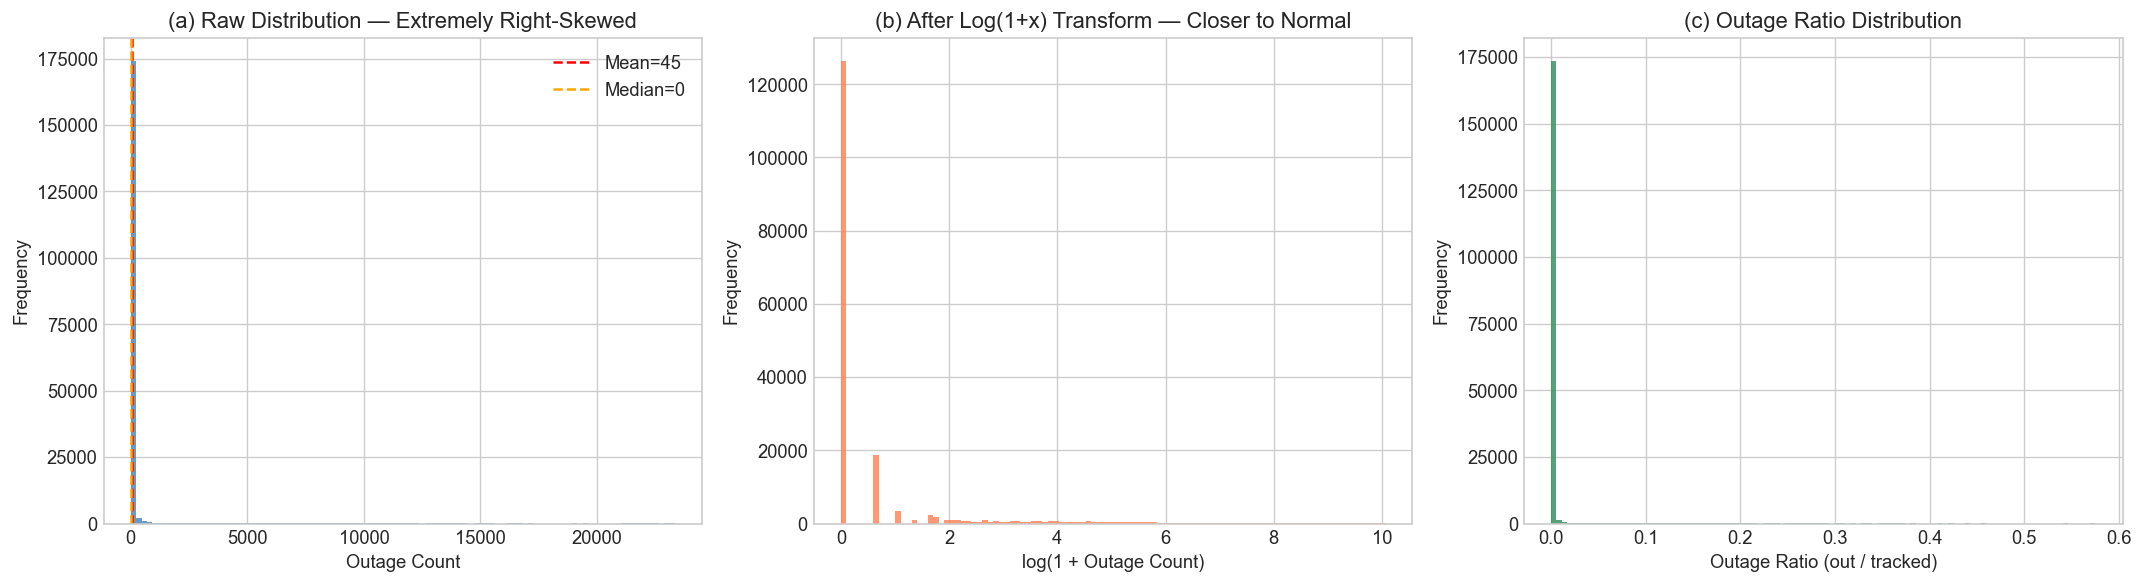

In [9]:
# Outage distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Raw distribution — heavily right-skewed
axes[0].hist(out_flat, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Outage Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('(a) Raw Distribution — Extremely Right-Skewed')
axes[0].axvline(np.nanmean(out_flat), color='red', linestyle='--', label=f'Mean={np.nanmean(out_flat):.0f}')
axes[0].axvline(np.nanmedian(out_flat), color='orange', linestyle='--', label=f'Median={np.nanmedian(out_flat):.0f}')
axes[0].legend()

# (b) Log(1+x) transform — closer to normal
out_log = np.log1p(out_flat)
axes[1].hist(out_log, bins=100, color='coral', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('log(1 + Outage Count)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('(b) After Log(1+x) Transform — Closer to Normal')

# (c) Outage ratio (out / tracked)
ratio = (out / tracked).flatten()
ratio = ratio[~np.isnan(ratio) & (ratio < 1)]
axes[2].hist(ratio, bins=100, color='seagreen', edgecolor='none', alpha=0.8)
axes[2].set_xlabel('Outage Ratio (out / tracked)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('(c) Outage Ratio Distribution')

plt.tight_layout()
plt.show()


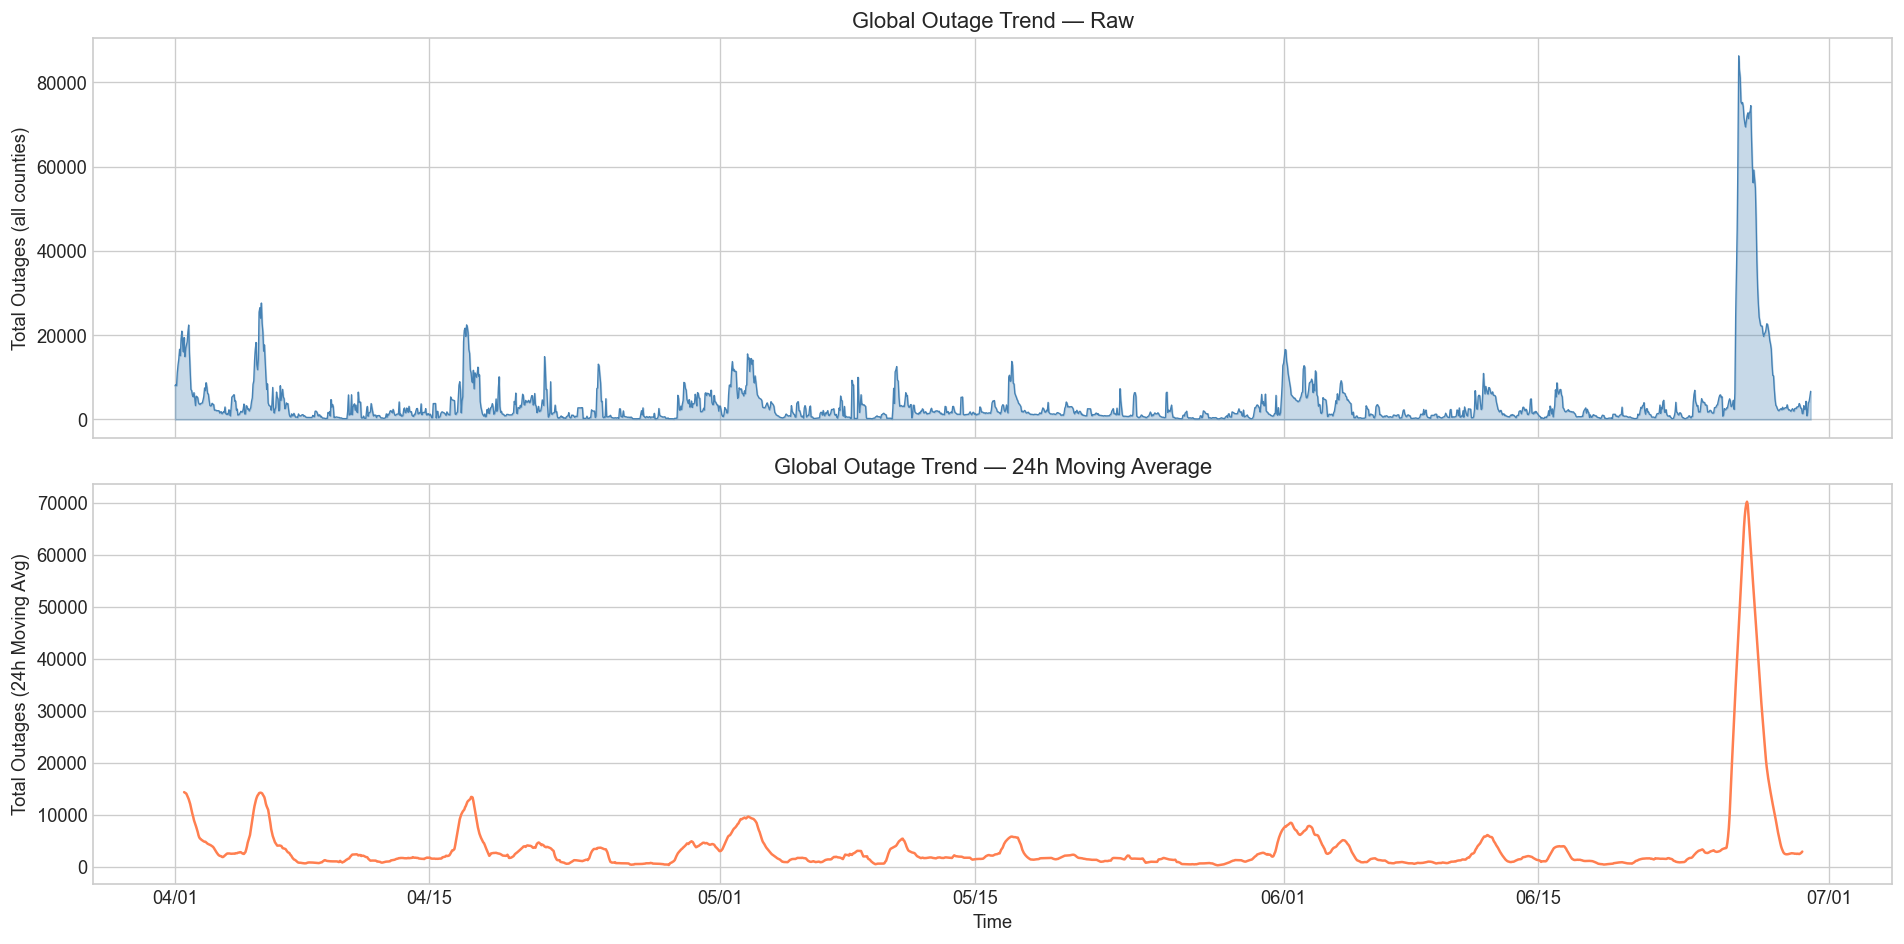


Extreme outage events (>99th percentile = 56608):
Total hours above threshold: 22
Distinct events: ~1
  2023-06-26 00:00


In [10]:
# 3.1 Global outage trend (sum across all counties)
total_outage_per_hour = np.nansum(out, axis=1)  # (T,)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Raw values
axes[0].plot(timestamps, total_outage_per_hour, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Total Outages (all counties)')
axes[0].set_title('Global Outage Trend — Raw')
axes[0].fill_between(timestamps, total_outage_per_hour, alpha=0.3, color='steelblue')

# 24h rolling average
rolling_24h = pd.Series(total_outage_per_hour).rolling(24, center=True).mean()
axes[1].plot(timestamps, rolling_24h, color='coral', linewidth=1.5)
axes[1].set_ylabel('Total Outages (24h Moving Avg)')
axes[1].set_title('Global Outage Trend — 24h Moving Average')
axes[1].set_xlabel('Time')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.tight_layout()
plt.show()

# Identify extreme spike events
threshold = np.nanpercentile(total_outage_per_hour, 99)
spike_mask = total_outage_per_hour > threshold
spike_times = timestamps[spike_mask]
print(f'\nExtreme outage events (>99th percentile = {threshold:.0f}):')
print(f'Total hours above threshold: {spike_mask.sum()}')
if len(spike_times) > 0:
    # Group consecutive hours into events
    gaps = np.diff(spike_times).astype('timedelta64[h]').astype(int)
    event_starts = [spike_times[0]]
    for i, gap in enumerate(gaps):
        if gap > 6:  # >6h gap = different event
            event_starts.append(spike_times[i+1])
    print(f'Distinct events: ~{len(event_starts)}')
    for t in event_starts:
        print(f'  {str(t)[:16]}')

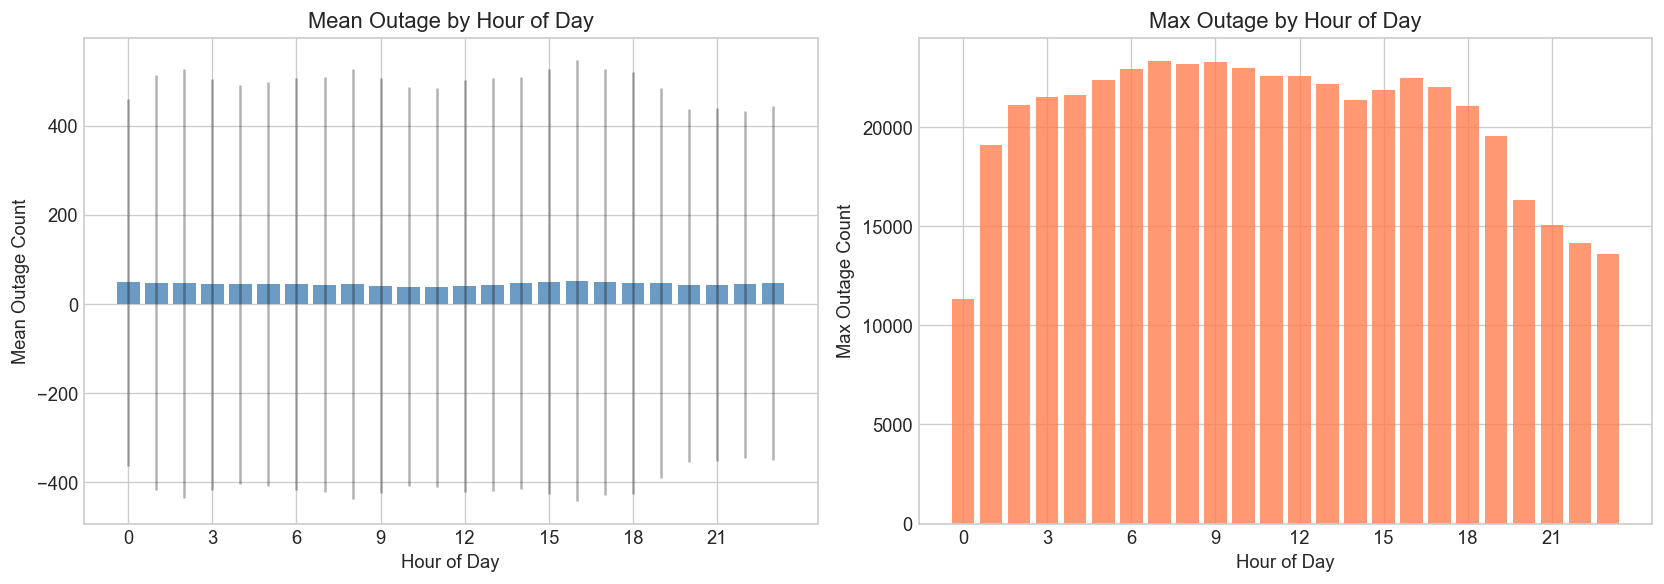


Peak hour:  16:00 (mean 52.8)
Low hour:   11:00 (mean 37.6)
Peak/Low ratio: 1.40x


In [11]:
# 3.2 Hour-of-day analysis — Is there a diurnal cycle?
hours = timestamps.hour

hourly_mean = np.zeros(24)
hourly_std = np.zeros(24)
hourly_max = np.zeros(24)

for h in range(24):
    mask = hours == h
    vals = out[mask].flatten()
    hourly_mean[h] = np.nanmean(vals)
    hourly_std[h] = np.nanstd(vals)
    hourly_max[h] = np.nanmax(vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean outage by hour
axes[0].bar(range(24), hourly_mean, color='steelblue', alpha=0.8)
axes[0].errorbar(range(24), hourly_mean, yerr=hourly_std, fmt='none', color='black', alpha=0.3)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Outage Count')
axes[0].set_title('Mean Outage by Hour of Day')
axes[0].set_xticks(range(0, 24, 3))

# Max outage by hour
axes[1].bar(range(24), hourly_max, color='coral', alpha=0.8)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Max Outage Count')
axes[1].set_title('Max Outage by Hour of Day')
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

peak_hour = np.argmax(hourly_mean)
low_hour = np.argmin(hourly_mean)
print(f'\nPeak hour:  {peak_hour}:00 (mean {hourly_mean[peak_hour]:.1f})')
print(f'Low hour:   {low_hour}:00 (mean {hourly_mean[low_hour]:.1f})')
print(f'Peak/Low ratio: {hourly_mean[peak_hour]/hourly_mean[low_hour]:.2f}x')

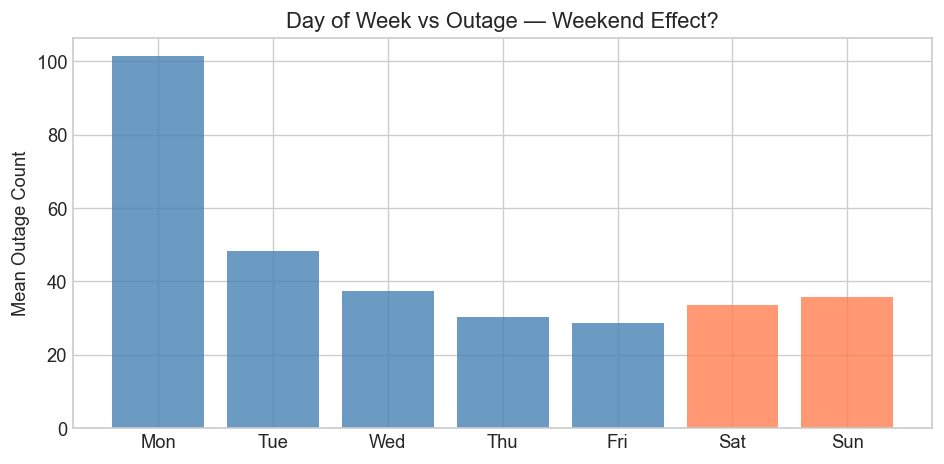

Weekday mean: 49.21
Weekend mean: 34.74
Difference:   29.4%


In [12]:
# 3.3 Day-of-week pattern
dow = timestamps.dayofweek  # 0=Monday
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow_mean = [np.nanmean(out[dow == d]) for d in range(7)]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue']*5 + ['coral']*2  # weekday vs weekend
ax.bar(dow_names, dow_mean, color=colors, alpha=0.8)
ax.set_ylabel('Mean Outage Count')
ax.set_title('Day of Week vs Outage — Weekend Effect?')
plt.tight_layout()
plt.show()

weekday_mean = np.mean(dow_mean[:5])
weekend_mean = np.mean(dow_mean[5:])
print(f'Weekday mean: {weekday_mean:.2f}')
print(f'Weekend mean: {weekend_mean:.2f}')
print(f'Difference:   {abs(weekday_mean-weekend_mean)/weekday_mean*100:.1f}%')

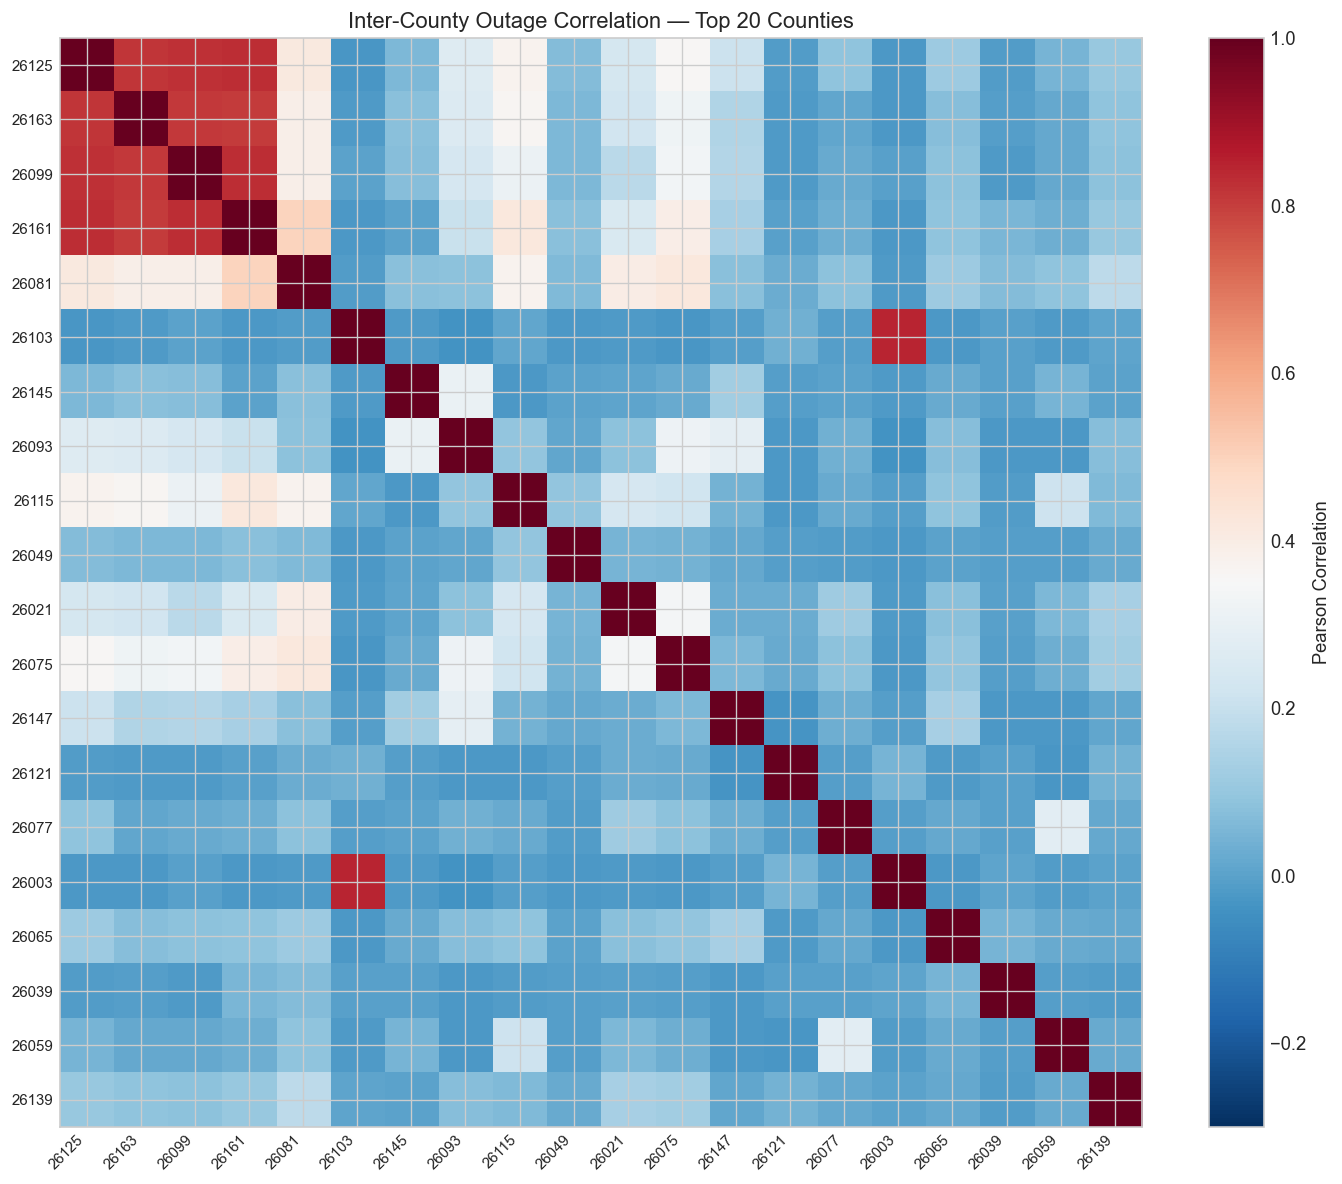


Inter-county correlation statistics:
  Mean:           0.106
  Pairs > 0.5:    7
  Pairs > 0.3:    25

=> Weak inter-county correlation. Counties can be modeled independently.


In [13]:
# Inter-county outage correlation matrix — detecting spatial propagation
# Use top 20 counties by outage count for visualization

county_total = out.sum(axis=0)
# Get top 20 counties
sort_idx = county_total.argsort()[::-1]
top20_idx = sort_idx[:20]
top20_labels = [locations[i] for i in top20_idx]
top20_out = out[:, top20_idx]  # (T, 20)

corr_matrix = np.corrcoef(top20_out.T)  # (20, 20)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.3, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(top20_labels)))
ax.set_yticks(range(len(top20_labels)))
ax.set_xticklabels(top20_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top20_labels, fontsize=9)
ax.set_title('Inter-County Outage Correlation — Top 20 Counties')
plt.colorbar(im, label='Pearson Correlation')
plt.tight_layout()
plt.show()

# Statistics on high-correlation pairs
upper_tri = corr_matrix[np.triu_indices(len(top20_labels), k=1)]
print(f'\nInter-county correlation statistics:')
print(f'  Mean:           {upper_tri.mean():.3f}')
print(f'  Pairs > 0.5:    {(upper_tri > 0.5).sum()}')
print(f'  Pairs > 0.3:    {(upper_tri > 0.3).sum()}')
if upper_tri.mean() > 0.2:
    print('\n=> Significant spatial correlation detected! GNN or neighbor features may be effective.')
else:
    print('\n=> Weak inter-county correlation. Counties can be modeled independently.')

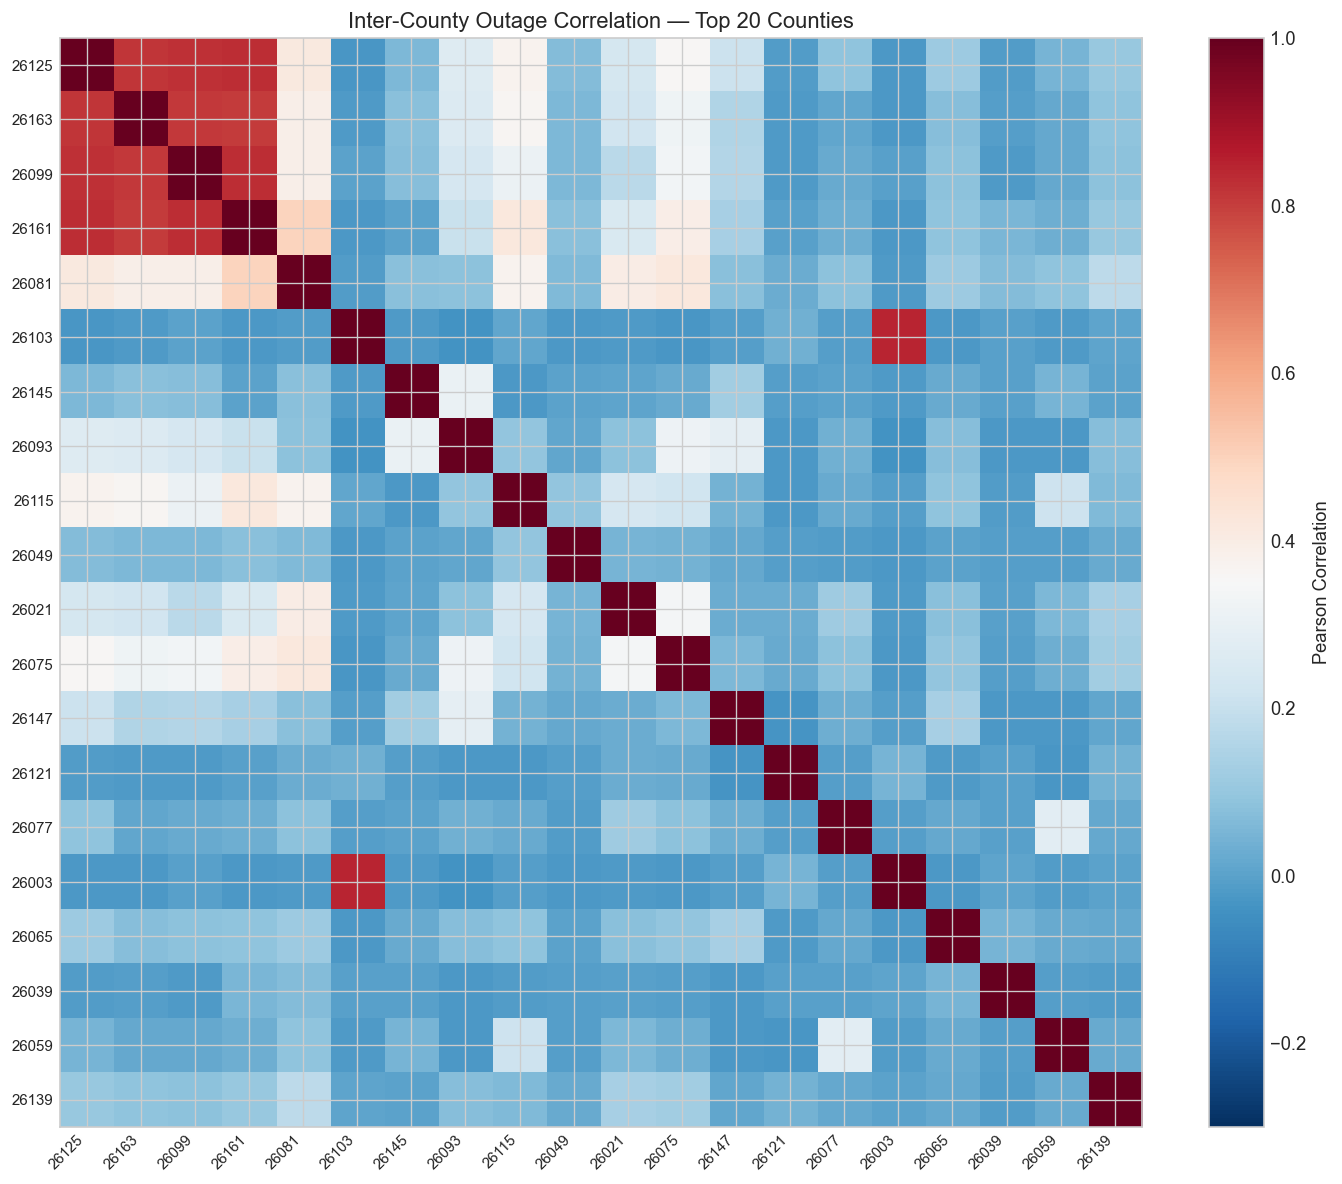


Inter-county correlation statistics:
  Mean:           0.106
  Pairs > 0.5:    7
  Pairs > 0.3:    25

=> Weak inter-county correlation. Counties can be modeled independently.


In [14]:
# Inter-county outage correlation matrix — detecting spatial propagation
# Use top 20 counties by outage count for visualization

county_total = out.sum(axis=0)
# Get top 20 counties
sort_idx = county_total.argsort()[::-1]
top20_idx = sort_idx[:20]
top20_labels = [locations[i] for i in top20_idx]
top20_out = out[:, top20_idx]  # (T, 20)

corr_matrix = np.corrcoef(top20_out.T)  # (20, 20)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.3, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(top20_labels)))
ax.set_yticks(range(len(top20_labels)))
ax.set_xticklabels(top20_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top20_labels, fontsize=9)
ax.set_title('Inter-County Outage Correlation — Top 20 Counties')
plt.colorbar(im, label='Pearson Correlation')
plt.tight_layout()
plt.show()

# Statistics on high-correlation pairs
upper_tri = corr_matrix[np.triu_indices(len(top20_labels), k=1)]
print(f'\nInter-county correlation statistics:')
print(f'  Mean:           {upper_tri.mean():.3f}')
print(f'  Pairs > 0.5:    {(upper_tri > 0.5).sum()}')
print(f'  Pairs > 0.3:    {(upper_tri > 0.3).sum()}')
if upper_tri.mean() > 0.2:
    print('\n=> Significant spatial correlation detected! GNN or neighbor features may be effective.')
else:
    print('\n=> Weak inter-county correlation. Counties can be modeled independently.')

In [15]:
# 5.1 Spearman correlation of each weather feature with outage (all counties pooled)
from scipy.stats import spearmanr

out_flat_all = out.flatten()  # (T*L,)

corr_with_outage = []
for f_idx, f_name in enumerate(features):
    weather_flat = weather[:, :, f_idx].flatten()  # (T*L,)

    # Drop NaN
    valid = ~(np.isnan(weather_flat) | np.isnan(out_flat_all))
    if valid.sum() > 100:
        rho, _ = spearmanr(weather_flat[valid], out_flat_all[valid])
    else:
        rho = 0.0
    corr_with_outage.append((f_name, rho, abs(rho)))

# # Sort by absolute correlation
corr_with_outage.sort(key=lambda x: -x[2])

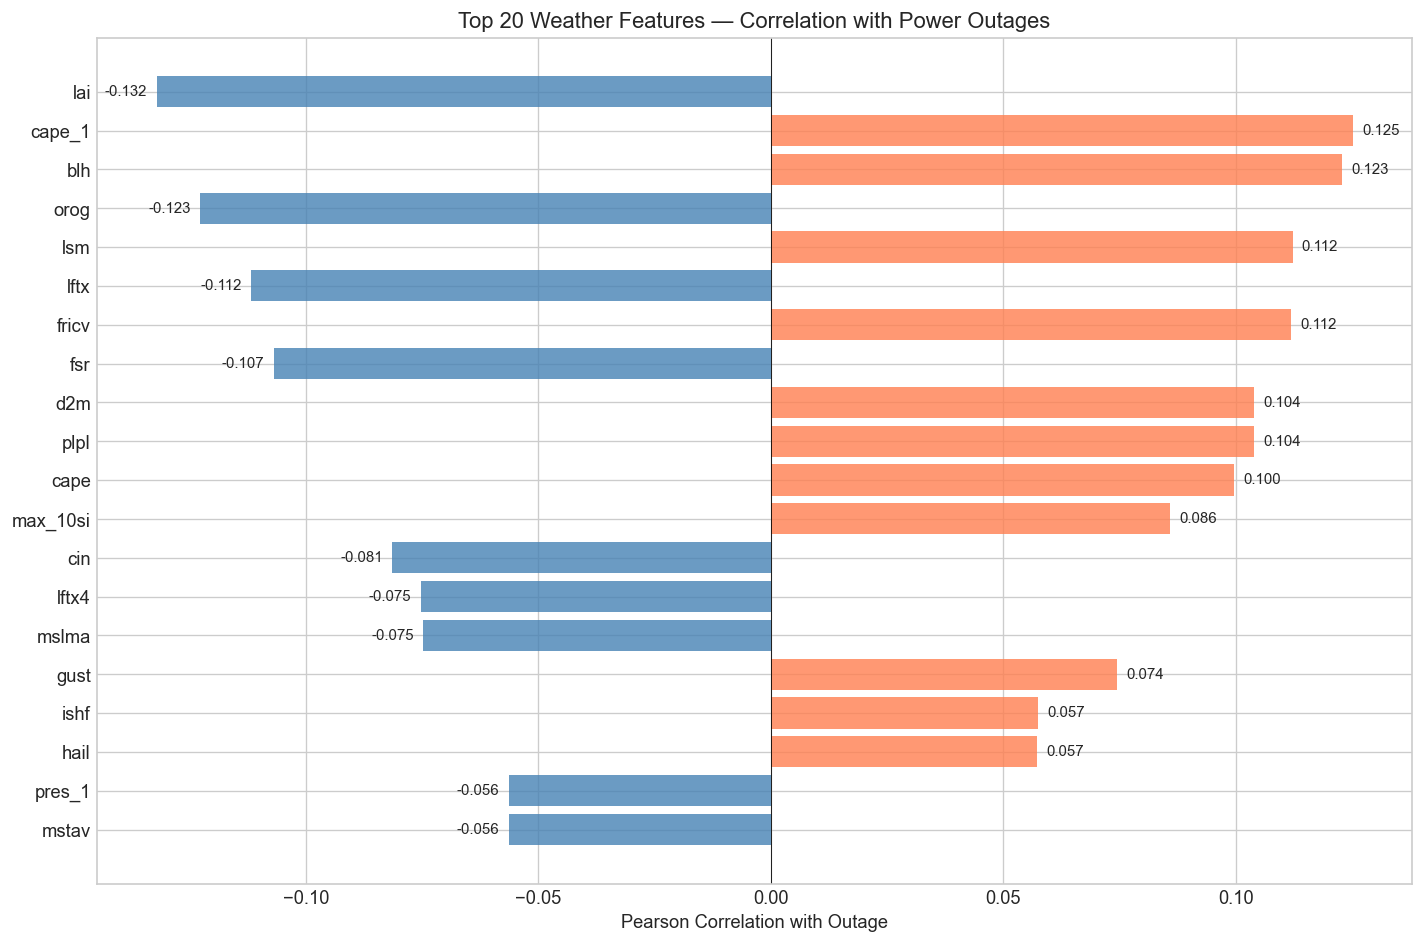

In [16]:
# # Visualization — Top 20 correlated features

top_n = 20
top_features = corr_with_outage[:top_n]

fig, ax = plt.subplots(figsize=(12, 8))
names = [x[0] for x in top_features][::-1]
values = [x[1] for x in top_features][::-1]
colors = ['coral' if v > 0 else 'steelblue' for v in values]

ax.barh(range(top_n), values, color=colors, alpha=0.8, edgecolor='none')
ax.set_yticks(range(top_n))
ax.set_yticklabels(names)
ax.set_xlabel('Pearson Correlation with Outage')
ax.set_title(f'Top {top_n} Weather Features — Correlation with Power Outages')
ax.axvline(0, color='black', linewidth=0.5)

for i, v in enumerate(values):
    ax.text(v + 0.002 if v > 0 else v - 0.002, i, f'{v:.3f}',
            va='center', ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


In [17]:
# Split: out == 0 → normal, out > 0 → extreme
valid_out = ~np.isnan(out.flatten())
extreme_mask = (out.flatten() > 0) & valid_out
normal_mask  = (out.flatten() == 0) & valid_out

print(f'Extreme samples: {extreme_mask.sum()} ({extreme_mask.mean()*100:.1f}%)')
print(f'Normal samples:  {normal_mask.sum()} ({normal_mask.mean()*100:.1f}%)')

Extreme samples: 52960 (29.5%)
Normal samples:  126403 (70.5%)


In [18]:
# 5.2 Check feature difference for extreme and normal data
# Split: out == 0 → normal, out > 0 → extreme
valid_out = ~np.isnan(out.flatten())
extreme_mask = (out.flatten() > 0) & valid_out
normal_mask  = (out.flatten() == 0) & valid_out

print(f'Extreme samples: {extreme_mask.sum()} ({extreme_mask.mean()*100:.1f}%)')
print(f'Normal samples:  {normal_mask.sum()} ({normal_mask.mean()*100:.1f}%)')

# Compute Cohen's d for each feature
diff_list = []
for f_idx, f_name in enumerate(features):
    w_flat = weather[:, :, f_idx].flatten()
    valid_w = ~np.isnan(w_flat)

    extreme_vals = w_flat[extreme_mask & valid_w]
    normal_vals  = w_flat[normal_mask  & valid_w]

    if len(extreme_vals) > 10 and len(normal_vals) > 10:
        pooled_std = np.sqrt((np.var(normal_vals) + np.var(extreme_vals)) / 2)
        if pooled_std > 0:
            cohens_d = (np.mean(extreme_vals) - np.mean(normal_vals)) / pooled_std
        else:
            cohens_d = 0.0
        diff_list.append((f_name, cohens_d, abs(cohens_d),
                          np.mean(normal_vals), np.mean(extreme_vals)))

diff_list.sort(key=lambda x: -x[2])

print(f'\n=== Extreme vs Normal Outage — Weather Feature Differences (Cohen\'s d) ===')
print(f'{"Rank":>4} {"Feature":<12} {"Cohen d":>10} {"Normal Mean":>14} {"Extreme Mean":>14} {"Effect":>10}')
print('-' * 72)

def effect_label(d):
    d = abs(d)
    if d >= 0.8:   return 'LARGE'
    elif d >= 0.5: return 'MEDIUM'
    elif d >= 0.2: return 'SMALL'
    else:          return 'negligible'

for i, (name, d, abs_d, nm, em) in enumerate(diff_list[:20]):
    print(f'{i+1:>4} {name:<12} {d:>+10.3f} {nm:>14.2f} {em:>14.2f} {effect_label(d):>10}')

# --- Split recommendation ---
abs_ds = [x[2] for x in diff_list]
n_large  = sum(d >= 0.8 for d in abs_ds)
n_medium = sum(0.5 <= d < 0.8 for d in abs_ds)
n_small  = sum(0.2 <= d < 0.5 for d in abs_ds)
n_negligible = sum(d < 0.2 for d in abs_ds)
mean_abs_d = np.mean(abs_ds)
max_abs_d  = np.max(abs_ds)

print(f'\n=== Split Recommendation ===')
print(f'Mean |Cohen d| across all features : {mean_abs_d:.3f}')
print(f'Max  |Cohen d|                     : {max_abs_d:.3f}')
print(f'Effect size breakdown — LARGE: {n_large}  MEDIUM: {n_medium}  SMALL: {n_small}  negligible: {n_negligible}')

if n_large >= 3 or mean_abs_d >= 0.5:
    verdict = 'SPLIT RECOMMENDED'
    reason  = 'Multiple features show large distributional shifts between normal and extreme outage conditions. A single model will struggle to fit both regimes — consider training separate models or adding an outage-occurrence binary flag as a feature.'
elif n_large >= 1 or mean_abs_d >= 0.2:
    verdict = 'SPLIT WORTH EXPLORING'
    reason  = 'Some features differ meaningfully between regimes. Try both a unified model and a split model and compare validation performance (e.g. RMSE on extreme vs. normal subsets separately).'
else:
    verdict = 'SPLIT LIKELY UNNECESSARY'
    reason  = 'Weather feature distributions are similar between normal and extreme outage samples. A single model should generalise across both regimes.'

print(f'\nVerdict: {verdict}')
print(f'Reason : {reason}')

Extreme samples: 52960 (29.5%)
Normal samples:  126403 (70.5%)

=== Extreme vs Normal Outage — Weather Feature Differences (Cohen's d) ===
Rank Feature         Cohen d    Normal Mean   Extreme Mean     Effect
------------------------------------------------------------------------
   1 orog             -0.327         271.88         248.47      SMALL
   2 vgtyp            +0.300          11.12          12.30      SMALL
   3 fsr              -0.294           0.41           0.34      SMALL
   4 lai              -0.287           1.68           1.30      SMALL
   5 lsm              +0.271           0.89           0.96      SMALL
   6 unknown_8        -0.263           4.19           3.26      SMALL
   7 t2m              +0.250          54.40          58.03      SMALL
   8 sh2              +0.247           0.01           0.01      SMALL
   9 fricv            +0.246           0.22           0.26      SMALL
  10 sdlwrf           +0.239         303.44         314.01      SMALL
  11 lftx         

In [19]:
# 6.1 Inter-feature correlation matrix (data pre)
# Use one representative county (the one with most outages)
mid_county_idx = sort_idx[0]
weather_one_county = weather[:, mid_county_idx, :]  # (T, F)

# Drop columns that are all NaN or constant
valid_features = []
valid_indices = []
for f_idx in range(F):
    col = weather_one_county[:, f_idx]
    if np.sum(~np.isnan(col)) > T * 0.5 and np.nanstd(col) > 0:
        valid_features.append(features[f_idx])
        valid_indices.append(f_idx)

weather_valid = weather_one_county[:, valid_indices]  # (T, F_valid)
print(f'Valid features: {len(valid_features)} / {F}')

# Compute correlation matrix via pandas (handles NaN)
df_weather = pd.DataFrame(weather_valid, columns=valid_features)
corr_features = df_weather.corr()

Valid features: 87 / 109


In [20]:
# 6.2 List highly redundant feature pairs
# use Pearson correlation to check correlation, and get r > 0.9 pairs
high_corr_pairs = []
corr_matrix_np = corr_features.values
feature_names_valid = corr_features.columns.tolist()

for i in range(len(feature_names_valid)):
    for j in range(i+1, len(feature_names_valid)):
        r = corr_matrix_np[i, j]
        if abs(r) > 0.9 and not np.isnan(r):
            high_corr_pairs.append((feature_names_valid[i], feature_names_valid[j], r))

high_corr_pairs.sort(key=lambda x: -abs(x[2]))

print(f'Highly correlated pairs (|r| > 0.9): {len(high_corr_pairs)} pairs')
print(f'\n{"Feature A":<12} {"Feature B":<12} {"Correlation":>12}')
print('-' * 38)
for a, b, r in high_corr_pairs[:20]:
    print(f'{a:<12} {b:<12} {r:>+12.4f}')

print(f'\n=> These pairs are highly redundant — keep only one from each pair.')
print(f'   Consider PCA or correlation-based feature selection for dimensionality reduction.')

Highly correlated pairs (|r| > 0.9): 49 pairs

Feature A    Feature B     Correlation
--------------------------------------
cpofp        lsm               -1.0000
cpofp        orog              -1.0000
lsm          unknown_8         +1.0000
lsm          vgtyp             +1.0000
orog         unknown_8         +1.0000
orog         vgtyp             +1.0000
unknown_8    vgtyp             +1.0000
cpofp        unknown_8         -1.0000
cpofp        vgtyp             -1.0000
lsm          orog              +1.0000
mslma        sp                +0.9997
sdswrf       suswrf            +0.9972
SBT114       SBT124            +0.9958
gh_6         gh_7              +0.9778
pt           t                 +0.9773
pres_1       pres_2            +0.9733
r            r_1               +0.9713
refd         refd_1            +0.9706
fricv        max_10si          +0.9653
lsm          mslma             +0.9646

=> These pairs are highly redundant — keep only one from each pair.
   Consider PCA or correla

Number of features involved: 38
['lsm', 'veg', 't', 'unknown_8', 'max_10si', 'fsr', 'pt', 'r', 'r2', 't2m', 'gh_7', 'sulwrf', 'sdswrf', 'u10', 'SBT114', 'gh', 'suswrf', 'pres_1', 'lai', 'cpofp', 'vis', 'mslma', 'orog', 'v', 'vgtyp', 'fricv', 'pres_2', 'SBT123', 'v10', 'SBT124', 'SBT113', 'gh_6', 'refd_1', 'r_1', 'sp', 'vbdsf', 'refd', 'u']


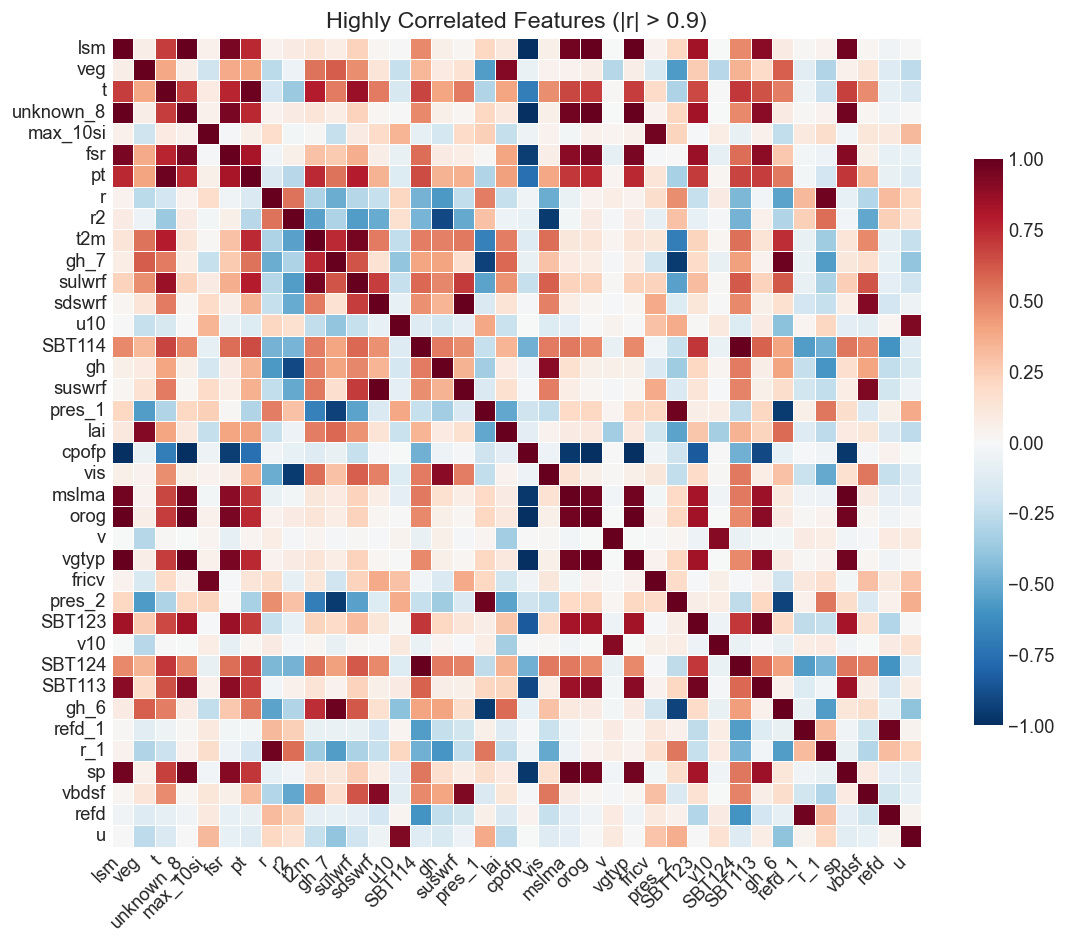

In [21]:
# 6.3 show heat map for above features
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Find highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
corr_matrix_np = corr_features.values
feature_names = corr_features.columns.tolist()

for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        r = corr_matrix_np[i, j]
        if not np.isnan(r) and abs(r) > 0.9:
            high_corr_pairs.append((feature_names[i], feature_names[j], r))

# Extract unique features involved
high_corr_features = list({f for pair in high_corr_pairs for f in pair[:2]})

print(f'Number of features involved: {len(high_corr_features)}')
print(high_corr_features)

# If no highly correlated features found, skip plotting
if len(high_corr_features) == 0:
    print("No highly correlated pairs found (|r| > 0.9).")
else:
    # Subset correlation matrix
    corr_subset = corr_features.loc[high_corr_features, high_corr_features]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_subset,
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        square=True,
        cbar_kws={'shrink': 0.7}
    )
    plt.title('Highly Correlated Features (|r| > 0.9)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [22]:
import sys, platform, struct, subprocess

print("Python exe:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("Architecture:", struct.calcsize("P") * 8, "bit")

subprocess.run([sys.executable, "-m", "pip", "--version"])

Python exe: c:\Users\yongh\AppData\Local\Programs\Python\Python314\python.exe
Python version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
Architecture: 64 bit


CompletedProcess(args=['c:\\Users\\yongh\\AppData\\Local\\Programs\\Python\\Python314\\python.exe', '-m', 'pip', '--version'], returncode=0)

In [23]:
import os
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# ── DEVICE CHECK ──────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ── CONFIG ────────────────────────────────────────────────
INPUT_FILE = "D:\Desktop\machine learning\data\cleaned_output.xlsx"
TARGET_COL = "log_out"
TRAIN_RATIO = 0.8
DROP_COLS = {"location", "timestamp", "tracked", "out", "state_x", "state_y"}
FORECAST_HORIZONS = [24, 48]
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

PARAM_GRID = {
    "look_back": [12, 24],
    "gru_units": [32, 64],
    "dropout": [0.1, 0.2],
    "batch_size": [16, 32],
    "epochs": [30]
}

# ── OUTPUT FOLDERS ───────────────────────────────────────
BASE_RESULT_DIR = "D:\Desktop\machine learning\gru_pytorch_result"

LOSS_DIR = os.path.join(BASE_RESULT_DIR, "loss")
PREDICT_DIR = os.path.join(BASE_RESULT_DIR, "predict")
BEST_PARAM_DIR = os.path.join(BASE_RESULT_DIR, "best_params")
FORECAST_DIR = os.path.join(BASE_RESULT_DIR, "forecast")
FORECAST_VISUAL_DIR = os.path.join(BASE_RESULT_DIR, "forecast_visual")

for d in [BASE_RESULT_DIR, LOSS_DIR, PREDICT_DIR, BEST_PARAM_DIR, FORECAST_DIR, FORECAST_VISUAL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── DATA PREP ─────────────────────────────────────────────
def prepare_data(df, look_back):
    feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in DROP_COLS]
    data = df[feature_cols].copy().ffill().bfill().fillna(0)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(data)
    y_scaled = scaler_y.fit_transform(data[[TARGET_COL]])

    X, y = [], []
    for i in range(look_back, len(X_scaled)):
        X.append(X_scaled[i - look_back:i])
        y.append(y_scaled[i])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    split = int(len(X) * TRAIN_RATIO)

    return X[:split], y[:split], X[split:], y[split:], scaler_y, X_scaled

# ── MODEL ────────────────────────────────────────────────
class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size, dropout):
        super().__init__()
        self.gru1 = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.gru2 = nn.GRU(
            input_size=hidden_size,
            hidden_size=max(hidden_size // 2, 1),
            batch_first=True
        )
        self.fc = nn.Linear(max(hidden_size // 2, 1), 1)

    def forward(self, x):
        out, _ = self.gru1(x)
        out = self.dropout(out)
        out, _ = self.gru2(out)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# ── TRAINING ─────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs, lr=0.001, patience=3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                preds = model(xb)
                loss = criterion(preds, yb)
                val_losses.append(loss.item())

        avg_train_loss = float(np.mean(train_losses))
        avg_val_loss = float(np.mean(val_losses))

        history["loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# ── PREDICT ──────────────────────────────────────────────
def predict_model(model, X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        preds = model(X_tensor).cpu().numpy()

    return preds

# ── FORECAST ─────────────────────────────────────────────
def forecast(model, last_window, scaler_y, steps):
    window = last_window.copy().astype(np.float32)
    preds = []

    for _ in range(steps):
        x_tensor = torch.tensor(window[np.newaxis, :, :], dtype=torch.float32).to(device)

        model.eval()
        with torch.no_grad():
            pred = model(x_tensor).cpu().numpy()[0, 0]

        preds.append(pred)

        new_row = window[-1].copy()
        target_idx = 0
        new_row[target_idx] = pred
        window = np.vstack([window[1:], new_row])

    return scaler_y.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

# ── PLOTS ────────────────────────────────────────────────
def plot_loss(history, name):
    plt.figure(figsize=(8, 4))
    plt.plot(history["loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title(f"{name} — Training Loss (PyTorch GRU)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.savefig(os.path.join(LOSS_DIR, f"{name}.png"), dpi=150)
    plt.close()

def plot_pred(y_true, y_pred, name):
    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.legend()
    plt.title(f"{name} — Actual vs Predicted (PyTorch GRU)")
    plt.xlabel("Time Step")
    plt.ylabel(TARGET_COL)
    plt.tight_layout()
    plt.savefig(os.path.join(PREDICT_DIR, f"{name}.png"), dpi=150)
    plt.close()

def plot_pred_with_forecast(y_true, y_pred, forecasts, name):
    n_actual = len(y_true)
    actual_idx = np.arange(n_actual)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(actual_idx, y_true, linewidth=1.5, label="Actual")
    ax.plot(actual_idx, y_pred, linewidth=1.2, linestyle="--", alpha=0.8, label="Predicted (test fit)")

    for h, fc_vals in forecasts.items():
        fc_idx = np.arange(n_actual - 1, n_actual - 1 + len(fc_vals) + 1)
        fc_line = np.concatenate([[y_true[-1]], fc_vals])
        ax.plot(fc_idx, fc_line, linewidth=1.8, label=f"{h}h Forecast")

    ax.axvline(x=n_actual - 1, linestyle=":", linewidth=1.2, label="Forecast start")

    ax.set_title(f"{name} — Actual vs Predicted vs Forecast (PyTorch GRU)")
    ax.set_xlabel("Time step")
    ax.set_ylabel(TARGET_COL)
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(FORECAST_VISUAL_DIR, f"{name}_forecast_plot.png"), dpi=150)
    plt.close(fig)

    print(f"Saved forecast plot → {os.path.join(FORECAST_VISUAL_DIR, f'{name}_forecast_plot.png')}")

# ── GRID SEARCH ──────────────────────────────────────────
def run_grid_search(df):
    keys = list(PARAM_GRID.keys())
    combos = list(itertools.product(*PARAM_GRID.values()))

    best_mse = float("inf")
    best_params = None
    best_model = None
    best_history = None
    best_y_true = None
    best_y_pred = None
    best_scaler = None

    for combo in combos:
        params = dict(zip(keys, combo))
        print(f"Testing params: {params}")

        try:
            X_tr, y_tr, X_val, y_val, scaler_y, _ = prepare_data(df, params["look_back"])
        except Exception:
            continue

        if len(X_tr) == 0 or len(X_val) == 0:
            continue

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.float32)
        )
        val_ds = TensorDataset(
            torch.tensor(X_val, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.float32)
        )

        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=False)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False)

        model = GRURegressor(
            input_size=X_tr.shape[2],
            hidden_size=params["gru_units"],
            dropout=params["dropout"]
        ).to(device)

        history = train_model(
            model,
            train_loader,
            val_loader,
            epochs=params["epochs"],
            lr=0.001,
            patience=3
        )

        pred = predict_model(model, X_val)
        y_true = scaler_y.inverse_transform(y_val)
        y_pred = scaler_y.inverse_transform(pred)

        mse = mean_squared_error(y_true, y_pred)

        if mse < best_mse:
            best_mse = mse
            best_params = params
            best_model = model
            best_history = history
            best_y_true = y_true
            best_y_pred = y_pred
            best_scaler = scaler_y

    return best_params, best_model, best_history, best_y_true, best_y_pred, best_scaler

# ── MAIN ────────────────────────────────────────────────
def main():
    sheets = pd.read_excel(INPUT_FILE, sheet_name=None)
    results = []
    all_forecasts = {}

    for name, df in sheets.items():
        print(f"\n=== {name} ===")

        best_params, model, history, y_true, y_pred, scaler_y = run_grid_search(df)

        if best_params is None:
            print(f"Skipped {name}: no valid model result.")
            continue

        print("Best params:", best_params)

        with open(os.path.join(BEST_PARAM_DIR, f"{name}_best_params.txt"), "w") as f:
            for k, v in best_params.items():
                f.write(f"{k}: {v}\n")

        plot_loss(history, name)
        plot_pred(y_true, y_pred, name)

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        results.append({
            "Sheet": name,
            "MSE": round(mse, 4),
            "MAE": round(mae, 4),
            "R2": round(r2, 4),
            **best_params
        })

        _, _, _, _, _, X_scaled = prepare_data(df, best_params["look_back"])
        last_window = X_scaled[-best_params["look_back"]:]
        forecasts = {h: forecast(model, last_window, scaler_y, h) for h in FORECAST_HORIZONS}
        all_forecasts[name] = forecasts

        plot_pred_with_forecast(
            y_true.flatten(),
            y_pred.flatten(),
            forecasts,
            name
        )

    metrics_path = os.path.join(BASE_RESULT_DIR, "sheet_metrics_gru_pytorch.xlsx")
    pd.DataFrame(results).to_excel(metrics_path, index=False)

    for h in FORECAST_HORIZONS:
        rows = []
        for loc, fc in all_forecasts.items():
            for i, v in enumerate(fc[h], 1):
                rows.append({
                    "Location": loc,
                    "Hour": i,
                    "Value": v
                })

        forecast_path = os.path.join(FORECAST_DIR, f"forecast_{h}h_gru_pytorch.xlsx")
        pd.DataFrame(rows).to_excel(forecast_path, index=False)

    print("\nDone")
    print(f"All results saved in: {BASE_RESULT_DIR}")

if __name__ == "__main__":
    main()

Using device: cpu

=== 26001 ===
Testing params: {'look_back': 12, 'gru_units': 32, 'dropout': 0.1, 'batch_size': 16, 'epochs': 30}
Testing params: {'look_back': 12, 'gru_units': 32, 'dropout': 0.1, 'batch_size': 32, 'epochs': 30}
Testing params: {'look_back': 12, 'gru_units': 32, 'dropout': 0.2, 'batch_size': 16, 'epochs': 30}
Testing params: {'look_back': 12, 'gru_units': 32, 'dropout': 0.2, 'batch_size': 32, 'epochs': 30}
Testing params: {'look_back': 12, 'gru_units': 64, 'dropout': 0.1, 'batch_size': 16, 'epochs': 30}
Testing params: {'look_back': 12, 'gru_units': 64, 'dropout': 0.1, 'batch_size': 32, 'epochs': 30}
Testing params: {'look_back': 12, 'gru_units': 64, 'dropout': 0.2, 'batch_size': 16, 'epochs': 30}
Testing params: {'look_back': 12, 'gru_units': 64, 'dropout': 0.2, 'batch_size': 32, 'epochs': 30}
Testing params: {'look_back': 24, 'gru_units': 32, 'dropout': 0.1, 'batch_size': 16, 'epochs': 30}
Testing params: {'look_back': 24, 'gru_units': 32, 'dropout': 0.1, 'batch_si

In [24]:
import os
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# ── CONFIG ────────────────────────────────────────────────
INPUT_FILE = "D:\Desktop\machine learning\data\cleaned_output.xlsx"
TARGET_COL = "log_out"
TRAIN_RATIO = 0.8
FORECAST_HORIZONS = [24, 48]

# ARIMA parameter grid
PARAM_GRID = {
    "p": [0, 1, 2],
    "d": [0, 1],
    "q": [0, 1, 2]
}

# ── OUTPUT FOLDERS ───────────────────────────────────────
BASE_RESULT_DIR = "D:\Desktop\machine learning"

LOSS_DIR = os.path.join(BASE_RESULT_DIR, "loss")
PREDICT_DIR = os.path.join(BASE_RESULT_DIR, "predict")
BEST_PARAM_DIR = os.path.join(BASE_RESULT_DIR, "best_params")
FORECAST_DIR = os.path.join(BASE_RESULT_DIR, "forecast")
FORECAST_VISUAL_DIR = os.path.join(BASE_RESULT_DIR, "forecast_visual")

for d in [BASE_RESULT_DIR, LOSS_DIR, PREDICT_DIR, BEST_PARAM_DIR, FORECAST_DIR, FORECAST_VISUAL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── DATA PREP ─────────────────────────────────────────────
def prepare_series(df):
    series = df[TARGET_COL].copy()
    series = pd.to_numeric(series, errors="coerce").ffill().bfill().fillna(0)
    split = int(len(series) * TRAIN_RATIO)

    train = series.iloc[:split].reset_index(drop=True)
    test = series.iloc[split:].reset_index(drop=True)

    return train, test, series

# ── ARIMA GRID SEARCH ─────────────────────────────────────
def run_grid_search(df):
    train, test, full_series = prepare_series(df)

    best_mse = float("inf")
    best_params = None
    best_model_fit = None
    best_y_true = None
    best_y_pred = None

    param_combos = list(itertools.product(
        PARAM_GRID["p"],
        PARAM_GRID["d"],
        PARAM_GRID["q"]
    ))

    for p, d, q in param_combos:
        order = (p, d, q)
        print(f"Testing params: order={order}")

        try:
            model = ARIMA(train, order=order)
            model_fit = model.fit()

            pred = model_fit.forecast(steps=len(test))
            y_true = test.values
            y_pred = np.array(pred)

            if len(y_true) == 0 or len(y_pred) == 0:
                continue

            mse = mean_squared_error(y_true, y_pred)

            if mse < best_mse:
                best_mse = mse
                best_params = {"p": p, "d": d, "q": q}
                best_model_fit = model_fit
                best_y_true = y_true
                best_y_pred = y_pred

        except Exception:
            continue

    return best_params, best_model_fit, best_y_true, best_y_pred, full_series

# ── PLOTS ────────────────────────────────────────────────
def plot_loss_placeholder(name):
    plt.figure(figsize=(8, 4))
    plt.text(0.5, 0.5, "ARIMA has no epoch-based training loss", ha="center", va="center", fontsize=12)
    plt.title(f"{name} — Training Loss (ARIMA)")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(LOSS_DIR, f"{name}.png"), dpi=150)
    plt.close()

def plot_pred(y_true, y_pred, name):
    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.legend()
    plt.title(f"{name} — Actual vs Predicted (ARIMA)")
    plt.xlabel("Time Step")
    plt.ylabel(TARGET_COL)
    plt.tight_layout()
    plt.savefig(os.path.join(PREDICT_DIR, f"{name}.png"), dpi=150)
    plt.close()

def plot_pred_with_forecast(y_true, y_pred, forecasts, name):
    n_actual = len(y_true)
    actual_idx = np.arange(n_actual)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(actual_idx, y_true, linewidth=1.5, label="Actual")
    ax.plot(actual_idx, y_pred, linewidth=1.2, linestyle="--", alpha=0.8, label="Predicted (test fit)")

    for h, fc_vals in forecasts.items():
        fc_idx = np.arange(n_actual - 1, n_actual - 1 + len(fc_vals) + 1)
        fc_line = np.concatenate([[y_true[-1]], fc_vals])
        ax.plot(fc_idx, fc_line, linewidth=1.8, label=f"{h}h Forecast")

    ax.axvline(x=n_actual - 1, linestyle=":", linewidth=1.2, label="Forecast start")

    ax.set_title(f"{name} — Actual vs Predicted vs Forecast (ARIMA)")
    ax.set_xlabel("Time step")
    ax.set_ylabel(TARGET_COL)
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(FORECAST_VISUAL_DIR, f"{name}_forecast_plot.png"), dpi=150)
    plt.close(fig)

    print(f"Saved forecast plot → {os.path.join(FORECAST_VISUAL_DIR, f'{name}_forecast_plot.png')}")

# ── FORECAST ─────────────────────────────────────────────
def make_forecasts(full_series, best_params):
    forecasts = {}

    for h in FORECAST_HORIZONS:
        model = ARIMA(full_series, order=(best_params["p"], best_params["d"], best_params["q"]))
        model_fit = model.fit()
        fc = model_fit.forecast(steps=h)
        forecasts[h] = np.array(fc)

    return forecasts

# ── MAIN ────────────────────────────────────────────────
def main():
    sheets = pd.read_excel(INPUT_FILE, sheet_name=None)
    results = []
    all_forecasts = {}

    for name, df in sheets.items():
        print(f"\n=== {name} ===")

        if TARGET_COL not in df.columns:
            print(f"Skipped {name}: missing {TARGET_COL}")
            continue

        best_params, model_fit, y_true, y_pred, full_series = run_grid_search(df)

        if best_params is None:
            print(f"Skipped {name}: no valid ARIMA result.")
            continue

        print("Best params:", best_params)

        # save best params txt
        with open(os.path.join(BEST_PARAM_DIR, f"{name}_best_params.txt"), "w") as f:
            for k, v in best_params.items():
                f.write(f"{k}: {v}\n")

        # plots
        plot_loss_placeholder(name)
        plot_pred(y_true, y_pred, name)

        # metrics
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        results.append({
            "Sheet": name,
            "MSE": round(mse, 4),
            "MAE": round(mae, 4),
            "R2": round(r2, 4),
            **best_params
        })

        # forecasts
        forecasts = make_forecasts(full_series, best_params)
        all_forecasts[name] = forecasts

        # combined plot
        plot_pred_with_forecast(
            y_true.flatten(),
            y_pred.flatten(),
            forecasts,
            name
        )

    # save metrics
    metrics_path = os.path.join(BASE_RESULT_DIR, "sheet_metrics_arima.xlsx")
    pd.DataFrame(results).to_excel(metrics_path, index=False)

    # save forecasts
    for h in FORECAST_HORIZONS:
        rows = []
        for loc, fc in all_forecasts.items():
            for i, v in enumerate(fc[h], 1):
                rows.append({
                    "Location": loc,
                    "Hour": i,
                    "Value": v
                })

        forecast_path = os.path.join(FORECAST_DIR, f"forecast_{h}h_arima.xlsx")
        pd.DataFrame(rows).to_excel(forecast_path, index=False)

    print("\nDone")
    print(f"All results saved in: {BASE_RESULT_DIR}")

if __name__ == "__main__":
    main()


=== 26001 ===
Testing params: order=(0, 0, 0)
Testing params: order=(0, 0, 1)
Testing params: order=(0, 0, 2)
Testing params: order=(0, 1, 0)
Testing params: order=(0, 1, 1)
Testing params: order=(0, 1, 2)
Testing params: order=(1, 0, 0)
Testing params: order=(1, 0, 1)
Testing params: order=(1, 0, 2)
Testing params: order=(1, 1, 0)
Testing params: order=(1, 1, 1)
Testing params: order=(1, 1, 2)
Testing params: order=(2, 0, 0)
Testing params: order=(2, 0, 1)
Testing params: order=(2, 0, 2)
Testing params: order=(2, 1, 0)
Testing params: order=(2, 1, 1)
Testing params: order=(2, 1, 2)
Best params: {'p': 1, 'd': 0, 'q': 0}
Saved forecast plot → D:\Desktop\machine learning\forecast_visual\26001_forecast_plot.png

=== 26003 ===
Testing params: order=(0, 0, 0)
Testing params: order=(0, 0, 1)
Testing params: order=(0, 0, 2)
Testing params: order=(0, 1, 0)
Testing params: order=(0, 1, 1)
Testing params: order=(0, 1, 2)
Testing params: order=(1, 0, 0)
Testing params: order=(1, 0, 1)
Testing pa